# 01-02 - A First Map of Princeton

In 01-01 we proved that the software works. Now we use it. We read three files off the disk, we look at what is inside them, and we draw them on top of each other until a town appears. Along the way we meet the object that carries everything spatial in this course, the GeoDataFrame, which is an ordinary table with one extraordinary column. We finish with a map you can click, and with a first honest look at what our data does not contain.

Before you change anything in this notebook, make it yours: choose File then Save As, and give it a name with `-mywork` in it, for example `01_02-mywork.ipynb`. Files named that way are ignored by the course repository, so your edits are yours and next week's material cannot overwrite them.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

Nothing appeared, and that is the correct outcome. An `import` makes a library's tools available to us, and `as` gives that library a short name, so `gpd` now means geopandas everywhere below. The short names are conventions rather than rules, but they are near universal, and using the same ones as everybody else means you can read other people's code and they can read yours.

Note that we do all our importing in one cell at the top. That is also a convention, and it exists so that anyone opening your notebook can see in five seconds what it depends on.

## Reading a spatial file

Our data lives in a folder called `data`, sitting beside this notebook. The first file we open holds the municipal boundary of Princeton.

It is a **GeoJSON** file, a plain text format for geographic data. Inside, it is a list of **features**, where one feature is one thing that has both a shape and some facts attached to it. Our boundary file contains exactly one feature: the outline of Princeton, with the name of the town attached.

It is worth saying once, early, what that file actually is. It is not the town. It is a claim about where the town's edge runs, made by the State of New Jersey and published through its open data portal. The Census Bureau publishes a slightly different claim, and the two disagree by about half a percent. Neither is lying. A boundary is a decision somebody recorded, not a fact you can measure off the ground, and that distinction will come back in 01-03.

When geopandas reads that file, it hands us a **GeoDataFrame**, which is an ordinary table in which one column holds shapes instead of numbers or text. Let us read the boundary off the disk:

In [2]:
boundary = gpd.read_file("data/princeton_boundary.geojson")

Nothing printed, because we stored the result rather than displaying it. The name `boundary` now refers to that table. Let us look at it:

In [3]:
boundary

,name,geometry
0,"Princeton, New Jersey","POLYGON ((-74.62252 40.3843, -74.62242 40.3842..."


We can see a table with exactly one row, numbered 0, and two columns, `name` and `geometry`. The `name` column holds the text `Princeton, New Jersey`. The `geometry` column holds something less familiar: a value starting `POLYGON ((-74.6...`, cut short with an ellipsis because the real outline of Princeton has several hundred corners and the table has no room for them.

Three pieces of vocabulary, and they are worth learning now because we use them all semester. The bold column on the left is the **index**, i.e. the label of each row, which here is just the row number. Each row is one **feature**. And the `geometry` column is what makes this a GeoDataFrame rather than an ordinary table.

Note also what we did not have to do. We wrote `boundary` on a line by itself and the table appeared. A notebook automatically displays the value of the last line of a cell, which is why no `print` was needed. That convenience will bite us exactly once, in 01-03, and we will point at it when it does.

## Drawing it

A table you can look at is good. A table you can see is better. Every GeoDataFrame carries a method called `plot` that draws its geometry column, and we reach it with a dot, i.e. we ask the table itself to draw itself.

Let us draw Princeton:

Text(0.5, 1.0, 'Princeton, New Jersey')

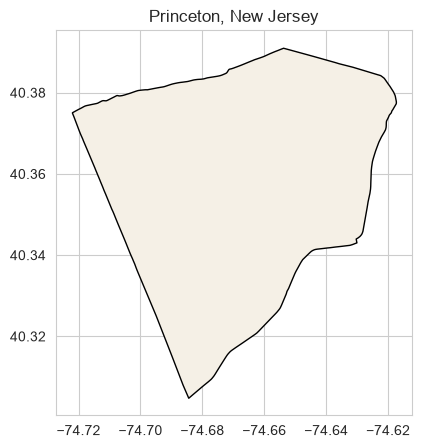

In [4]:
ax = boundary.plot(figsize=(5, 5), color="#f5f0e6", edgecolor="black")
ax.set_title("Princeton, New Jersey")

Four things went into that call, and it is worth naming each one:

- `figsize=(5, 5)` is the size of the picture in inches, width first and then height.
- `color` is the fill of the polygon.
- `edgecolor` is the line drawn around it.
- `ax` is not an argument at all. It is the name we gave to the thing `plot` handed back, i.e. the drawing surface it made. We will need it in a moment.

Now read the picture. One shape, with the horizontal axis running from about -74.72 to -74.62 and the vertical from about 40.30 to 40.39. Note that those two ranges are almost the same width, 0.10 and 0.09, yet Princeton is noticeably wider than it is tall on the ground. The picture is stretched, and 01-03 explains exactly why.

## Two more layers

A boundary on its own is an outline. To make it a town we need what is inside it, so we add two more files.

Both come from **OpenStreetMap**, a map of the world built by volunteers, in the same spirit as Wikipedia. Anybody can add a building or a restaurant, and that fact shapes everything about the data, in ways we will look at squarely later in this notebook.

The two files hold the buildings of Princeton and the places you can eat in it. They are a pinned snapshot taken on 2026-08-29, saved once and committed to this repository, so that nothing in the classroom depends on a live service being in a good mood. OpenStreetMap data is licensed ODbL, which requires attribution, and the credit travels inside the files themselves.

Let us read both of them:

In [5]:
buildings = gpd.read_file("data/princeton_buildings.geojson")
food = gpd.read_file("data/princeton_food.geojson")

Two more files, and again nothing printed. How much did we just load:

In [6]:
print(f"{len(buildings)} buildings, {len(food)} places to eat")

7893 buildings, 92 places to eat


We can see 7893 buildings and 92 places to eat. The function `len` counts the rows of a table, and here one row is one building, so 7893 is a count of things rather than of bytes or of files.

Both numbers are worth holding on to, and the ratio between them is worth a moment's thought. Nearly eight thousand buildings, and 92 restaurants, cafes and takeaways, inside a municipality of about 48 square kilometres.

Note carefully what these numbers are not. They are not the buildings in Princeton. They are the buildings somebody has drawn in Princeton, which is a different quantity, and the gap between the two is the subject of the extension notebook 01-05.

Counting tells us how much. Looking tells us what. Here are the first five rows of the food table:

In [7]:
food.head()

,name,amenity,geometry
0,Metro North,restaurant,POINT (-74.65398 40.33471)
1,Roots Ocean Prime,restaurant,POINT (-74.65944 40.34333)
2,Starbucks,cafe,POINT (-74.65946 40.34993)
3,Tacoria,fast_food,POINT (-74.65912 40.35003)
4,Maruichi Japanese Food & Deli,restaurant,POINT (-74.65827 40.35026)


Three columns this time: `name`, `amenity` and `geometry`. The names are real places you can walk to this afternoon.

Look at the geometry column and compare it with the boundary. There we saw `POLYGON`. Here we see `POINT (-74.65 40.35)`, a single pair of numbers. That difference is not a quirk of the file format, it is a decision somebody made about the world: a restaurant is recorded as one location, while a municipality is recorded as an outline. The **geometry type** is a property of the data.

The `amenity` column is OpenStreetMap's own vocabulary for what kind of place each one is. We did not choose those words and we cannot change them, which matters as soon as we try to filter by them.

Note that `head` shows five rows by default and takes a number if you want a different amount, so `food.head(20)` also works.

## Putting the layers together

So far each `plot` call made its own picture. To get three layers in one map, they all have to draw onto the same surface.

That surface is the `ax` we met earlier. When you call `plot` without telling it where to draw, it makes a fresh surface and hands it back. When you pass `ax=ax`, you are saying: draw onto that one instead.

Note that order matters, because whatever is drawn last sits on top. We draw the boundary first as a background, then the buildings, then the places to eat, so that the small orange dots are not buried under seven thousand grey shapes.

Let us put all three on one pair of axes:

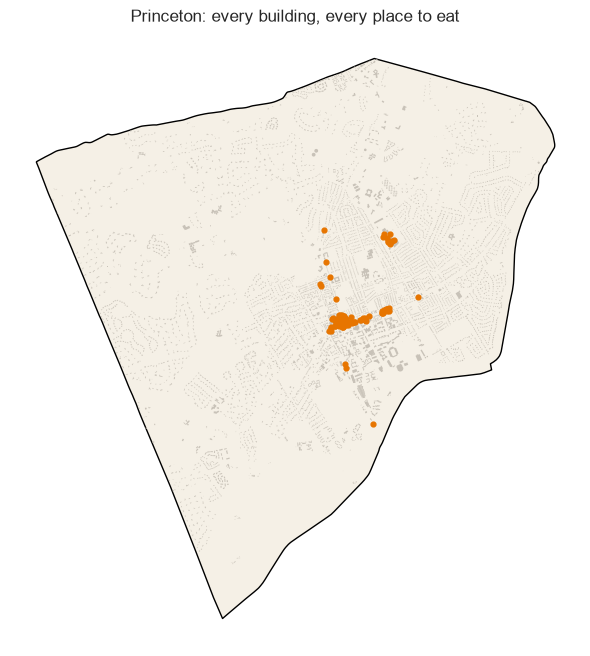

In [8]:
ax = boundary.plot(figsize=(8, 8), color="#f5f0e6", edgecolor="black", linewidth=1)
buildings.plot(ax=ax, color="#c8c2b8", linewidth=0)
food.plot(ax=ax, color="#e77500", markersize=12)

ax.set_title("Princeton: every building, every place to eat")
ax.set_axis_off()

We can see a town. Now read it carefully, including the parts that look wrong, because three things about this picture are worth naming and none of them is a bug.

**Most of the map is empty, and that emptiness is real.** The places to eat occupy a box roughly 1.7 kilometres wide and 3.3 kilometres tall, inside a municipality about 8.9 by 9.6 kilometres across. So around nineteen twentieths of what you are looking at genuinely has no restaurant in it. That is the shape of the town, not a gap in the data.

**The buildings look like a grey smear rather than 7893 separate shapes.** At this size each footprint is smaller than a single pixel on your screen, so they merge. Zooming in would separate them. All the buildings together cover about 2.4 of the 48 square kilometres, i.e. around five percent of what is drawn.

**The axes are gone, because we turned them off.** Look at what that cost us. Nothing on the page now says where on Earth this is, or how big it is, or which way is north. The map looks more finished and is less checkable, and that is a trade you should make on purpose rather than by habit. It is also, as we will see in 01-04, a trade an AI will quietly make for you.

## A map you can touch

Static pictures are for reports. For finding your way around your own data, an interactive map is far better, and geopandas will build one with `explore` in place of `plot`.

We pass two layers only, the boundary and the 92 places to eat. We deliberately leave the buildings out. An interactive map writes every shape into the page as text, and 7893 building outlines come to roughly three megabytes of geometry, which makes the result crawl. Rendering cost is a real design constraint, and it is worth meeting it here rather than on the evening before your poster is due.

Let us make a map you can click:

In [9]:
webmap = boundary.explore(color="#e77500", style_kwds={"fill": False, "weight": 3})
webmap = food.explore(m=webmap, color="#e77500", tooltip=["name", "amenity"])
webmap

This one you can use. Scroll to zoom, drag to pan, and click any orange dot to see its name and its kind. Find a place you have actually eaten at. Find one you did not know existed.

Two things to notice. The `m=webmap` argument is the same idea as `ax=ax` from the static map: it says draw onto the map we already have, rather than starting a new one. And the `tooltip` argument takes a list of column names, which is why we wrote `["name", "amenity"]` with square brackets.

Note where the background comes from. Those streets and labels are not our data. They are images fetched from a tile service on the internet, drawn underneath our two layers. If the background is blank or grey, your analysis is unaffected, you simply have no backdrop. That distinction between your data and the picture behind it matters more than it sounds, and 01-08 has a story about it.

## Change one thing

This is yours to play with, now or later. Nothing here is assessed, and the fastest way to learn what a line of code does is to change it and see what moves.

**Knob one.** In the layered map above, change `color="#e77500"` to any colour name, for example `"purple"`, and change `markersize=12` to something larger. Re-run that cell.

**Knob two.** In the cell below, swap `"cafe"` for `"pizza"` and run it. Something interesting happens, and the notebook does not complain. Read the section under it before you decide why.

**Knob three.** Add your own dorm or house to the map. You will need its longitude and latitude, which you can get by pressing and holding on the spot in your phone's map application. Remember the order: longitude first, then latitude. We build points properly in 01-04.

In [10]:
cafes = food[food["amenity"] == "cafe"]

print(f"{len(cafes)} of {len(food)} food places match")
cafes[["name", "amenity"]].head(10)

15 of 92 food places match


,name,amenity
2,Starbucks,cafe
17,illy Coffee At Earth's End Princeton,cafe
18,Ellinikon,cafe
24,Fresh Ó Tea,cafe
29,Small World Coffee,cafe
44,Starbucks,cafe
47,Kung Fu Tea,cafe
51,Small World Coffee,cafe
57,Sakrid Coffee Roasters,cafe
60,Rojo's Roastery,cafe


We can see 15 cafes out of 92, and their names.

The line that did the work reads `food[food["amenity"] == "cafe"]`, and it is worth taking apart because this pattern appears in every notebook from here on. The inner part, `food["amenity"] == "cafe"`, compares every value in the `amenity` column against the text `cafe` and produces a column of True and False, one for each of the 92 rows. Putting that column inside `food[...]` keeps the rows where it said True.

Note the double equals. A single `=` gives something a name, as in `cafes = ...`. A double `==` asks whether two things are equal. Confusing them is a rite of passage.

Now, knob two. If you swapped `cafe` for `pizza`, you got 0 of 92 and an empty table, with no error at all. Nothing is broken. It is simply that `pizza` is not one of OpenStreetMap's amenity values: the vocabulary is theirs, and it runs restaurant, fast_food, cafe, ice_cream, pub, bar. A filter that matches nothing is not an error, and that is precisely why it is dangerous. Silence can mean no matching rows, or it can mean you have misspelled a value. In this course we make a habit of checking counts rather than trusting silence.

## Check your understanding

Try these before moving on to 01-03. The answers are all things you have already seen.

1. `food.head()` printed five rows. How would you print three?
2. In the layered map, the buildings were drawn before the food. What would change if you swapped those two lines?
3. `len(food)` gave 92. Without running anything, what do you think `len(boundary)` gives, and why?
4. The cafe filter returned 15 rows. What would `len(food[food["amenity"] == "bar"])` return? You can find out from the table in the next cell.

In [11]:
food["amenity"].value_counts()

amenity
restaurant    52
fast_food     16
cafe          15
ice_cream      6
pub            2
bar            1
Name: count, dtype: int64

That is the whole vocabulary of the food layer, sorted from the most common to the least: 52 restaurants, then 16 fast food places, 15 cafes, 6 ice cream shops, 2 pubs and a single bar. The method `value_counts` is how you learn what is actually in a column, as opposed to what you assume is in it, and it is usually the first thing worth running on any column you have not seen before.

Note that these six values add to 92, which is the number of rows we counted right at the start. When a breakdown adds up to the total you already know, you have learned something small and reassuring: no rows were dropped and none was counted twice.

## Where we are, and what is next

We have a map of Princeton with three layers on it, we can filter it, and we can click it. In under half an hour, with no prior Python, that is a genuine piece of work.

We have also not checked a single thing. We have not asked whether that file really contains Princeton, New Jersey. We have not asked what those numbers along the axes mean, or what units they are in, or whether the area of the shape is what we would expect. We drew a map and believed it, which is exactly what everybody does and exactly what this course is going to talk you out of.

That is 01-03, and it is the notebook the rest of the semester rests on.

## Further resources

Nothing in this course requires anything below, and everything you needed for this notebook was in this notebook. These are for going further.

**The libraries.** The GeoPandas user guide covers reading files, plotting and everything else with `gpd` in front of it: https://geopandas.org/en/stable/docs/user_guide.html. Its gallery of mapping examples is the fastest way to see what is possible: https://geopandas.org/en/stable/gallery/index.html. Matplotlib's pyplot tutorial explains figures and axes, i.e. what the `ax` we kept passing around actually is: https://matplotlib.org/stable/tutorials/pyplot.html.

**The data.** The buildings and the places to eat are an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright. If you want to know what the `amenity` values mean, OpenStreetMap documents its own vocabulary at https://wiki.openstreetmap.org/wiki/Key:amenity. The municipal boundary is a public record from NJGIN Open Data: https://njogis-newjersey.opendata.arcgis.com.

**If you want a slower pass over Python itself,** the `F00` folder in this repository is our own foundations series, written for exactly this course and using this same Princeton data throughout.